In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
pipedata1 = pd.read_csv('pipedata.csv')

In [26]:
columns = ['pipe_size','thickness','mat','grade','max_press','temp','corr_per','thickness_loss','mat_percent','time_years','condition']

In [28]:
pipedata1.columns = columns

In [16]:
df = pipedata1.loc[pipedata1['mat_percent'] <= 100].reset_index(drop =True)

,pipe_size,thickness,max_press,temp,corr_per,thickness_loss,mat_percent,time_years
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,522.000000,16.073530,1004.100000,42.595600,9.745990,4.886300,46.747560,12.961000
std,443.703587,10.548358,812.843099,41.127071,5.817492,2.901123,46.602553,7.135993
min,50.000000,3.000000,150.000000,-50.000000,0.000000,0.010000,0.080000,1.000000
25%,150.000000,7.357500,300.000000,13.400000,4.492500,2.365000,15.665000,7.000000
50%,300.000000,12.930000,900.000000,41.200000,9.720000,4.915000,31.660000,13.000000
75%,800.000000,23.027500,1500.000000,69.150000,14.832500,7.432500,61.035000,19.000000
max,1500.000000,49.530000,2500.000000,149.700000,20.000000,9.990000,318.750000,25.000000


In [84]:
df['condition'].value_counts(normalize = True).round(2)*100

condition
Critical    43.0
Moderate    33.0
Normal      24.0
Name: proportion, dtype: float64

In [86]:
df.groupby('condition')['max_press'].mean()

condition
Critical     997.466667
Moderate    1018.150685
Normal       985.046729
Name: max_press, dtype: float64

In [88]:
df.groupby('condition')['temp'].mean()

condition
Critical    43.665067
Moderate    39.411301
Normal      44.617290
Name: temp, dtype: float64

In [90]:
df.groupby('condition')['time_years'].mean()

condition
Critical    12.642667
Moderate    13.363014
Normal      12.621495
Name: time_years, dtype: float64

In [92]:
df.groupby('condition')['corr_per'].mean()

condition
Critical    9.769173
Moderate    9.584795
Normal      9.854346
Name: corr_per, dtype: float64

In [94]:
df.groupby('condition')['thickness_loss'].mean()

condition
Critical    7.335253
Moderate    3.506712
Normal      0.924299
Name: thickness_loss, dtype: float64

In [96]:
df.groupby('condition')['mat_percent'].mean()

condition
Critical    46.079120
Moderate    33.809486
Normal       8.837523
Name: mat_percent, dtype: float64

In [98]:
## Corrosion is influenced by both environmental conditions as well as the pipe properties
## the corrosion impact percentage describes the environments corrosive potential and not the response of the pipe 
## note that two pipe placed in the same enviromwent can respond differently to corrosion depending on the properties of the pipe(material and thickness)

In [100]:
df['corr_per'].describe()

count    881.000000
mean       9.728751
std        5.813849
min        0.000000
25%        4.510000
50%        9.650000
75%       14.820000
max       20.000000
Name: corr_per, dtype: float64

In [102]:
df.groupby('mat')['thickness_loss'].mean().sort_values(ascending = False)

mat
PVC                4.905031
HDPE               4.607396
Stainless Steel    4.538933
Fiberglass         4.506495
Carbon Steel       4.023277
Name: thickness_loss, dtype: float64

In [104]:
df.groupby('mat')['condition'].value_counts(normalize = True).round(2)*100

mat              condition
Carbon Steel     Critical     37.0
                 Normal       34.0
                 Moderate     29.0
Fiberglass       Critical     41.0
                 Moderate     40.0
                 Normal       19.0
HDPE             Critical     44.0
                 Moderate     33.0
                 Normal       23.0
PVC              Critical     50.0
                 Moderate     28.0
                 Normal       21.0
Stainless Steel  Critical     42.0
                 Moderate     34.0
                 Normal       24.0
Name: proportion, dtype: float64

In [106]:
df.groupby('grade')['thickness_loss'].mean().sort_values()

grade
ASTM A106 Grade B    4.189734
API 5L X42           4.371519
ASTM A333 Grade 6    4.488150
API 5L X65           4.754085
API 5L X52           4.776667
Name: thickness_loss, dtype: float64

In [108]:
df.groupby('grade')['condition'].value_counts(normalize = True).round(2)*100

grade              condition
API 5L X42         Critical     37.0
                   Moderate     35.0
                   Normal       28.0
API 5L X52         Critical     47.0
                   Moderate     35.0
                   Normal       18.0
API 5L X65         Critical     48.0
                   Moderate     30.0
                   Normal       22.0
ASTM A106 Grade B  Moderate     37.0
                   Critical     36.0
                   Normal       27.0
ASTM A333 Grade 6  Critical     44.0
                   Moderate     30.0
                   Normal       26.0
Name: proportion, dtype: float64

## In depth analsysis into  Carbon Steel Pipe

In [34]:
carbon = pipedata1[pipedata1['mat'] == 'Carbon Steel'].reset_index(drop = True)

In [36]:
carbon.groupby('condition')['thickness_loss'].describe()

,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
Critical,97.0,7.250412,1.448040,5.01,6.0000,7.410,8.3400,9.96
Moderate,53.0,3.747736,0.882565,2.04,3.0200,3.890,4.6100,5.00
Normal,60.0,1.082667,0.514201,0.07,0.6925,1.075,1.5325,1.95


In [38]:
## if you observe the data you can find that the transition zone to critical lies from 4.61 to 6.00( it is advised that when 6mm of the pipe has been lost
## it should be changed, same for the transition zone between normal and moderate it starts at 1.5325 to 3.02, above this your pipe isn't normal anymore

In [40]:
import matplotlib.pyplot as plt

In [42]:
cs_critical = carbon[carbon['condition'] == 'Critical']['thickness_loss']

In [44]:
cs_critical

1      6.32
2      6.20
3      5.86
5      9.21
7      7.59
       ... 
203    7.64
204    8.04
205    7.99
206    6.32
208    7.92
Name: thickness_loss, Length: 97, dtype: float64

In [ ]:
cs_mod = carbon.loc[carbon['condition'] == 'Moderate','thickness_loss']

In [54]:
cs_norm = carbon[carbon['condition'] == 'Normal']['thickness_loss']

C:\Users\Derah\AppData\Local\Temp\ipykernel_14840\182099088.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([cs_norm,cs_mod,cs_critical], labels = ['Normal','Moderate','Critical'],patch_artist = True,boxprops = dict(facecolor = 'lightblue'))


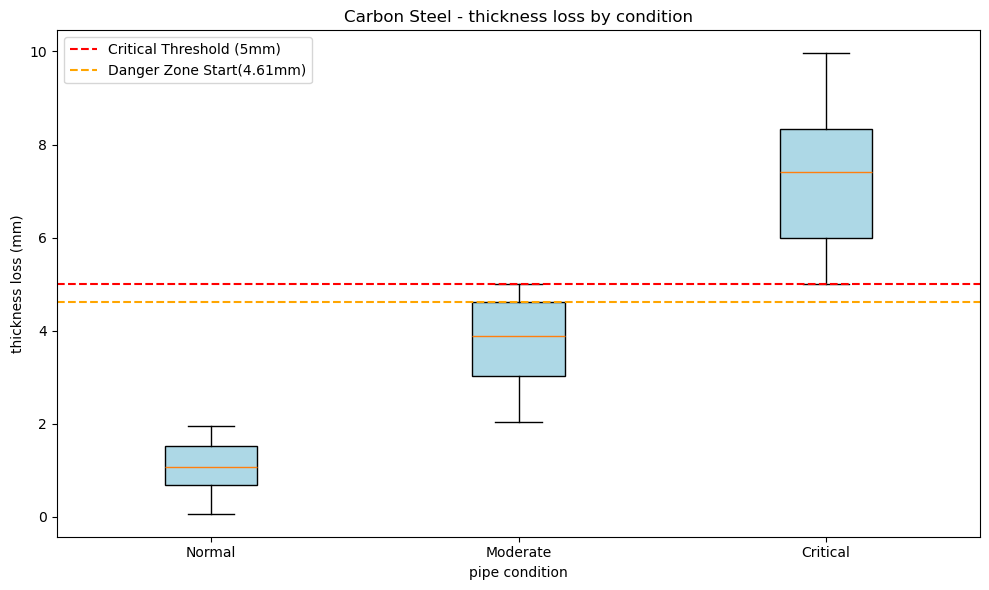

In [56]:
plt.figure(figsize = (10,6))
plt.boxplot([cs_norm,cs_mod,cs_critical], labels = ['Normal','Moderate','Critical'],patch_artist = True,boxprops = dict(facecolor = 'lightblue'))
plt.axhline(y = 5.0, color = 'red', linestyle = '--',linewidth = 1.5, label = 'Critical Threshold (5mm)')
plt.axhline(y = 4.61, color = 'orange', linestyle = '--',linewidth = 1.5, label = 'Danger Zone Start(4.61mm)')
plt.title('Carbon Steel - thickness loss by condition')
plt.ylabel('thickness loss (mm)')
plt.xlabel('pipe condition')
plt.legend()
plt.tight_layout()
plt.show()

In [58]:
carbon.groupby('condition')['mat_percent'].describe()

,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
Critical,97.0,76.278144,58.540294,12.73,29.5900,54.72,111.880,318.75
Moderate,53.0,38.727170,25.854760,7.29,19.5600,31.60,54.370,137.67
Normal,60.0,9.495000,8.309914,0.65,3.7575,6.90,12.565,39.75
